# 04 — Statistical feature vectors

*Source:* Claude Code

**What it measures.** Instead of aligning two series sample by sample, this approach
*summarises* each series into a fixed-length feature vector — mean, standard deviation,
min, max, skewness, kurtosis, zero-crossing rate, dominant FFT frequency, spectral
energy and the first three autocorrelation coefficients — and then measures the ordinary
Euclidean distance between those vectors.

**Key idea.** Similarity is defined in *feature space*, not in signal space:

```
d(x, y) = || z(f(x)) - z(f(y)) ||_2
```

where `f` extracts the 12 features and `z` standardises each feature across the dataset
so that a feature measured in "volts squared" cannot dominate one measured in "cycles
per sample".

**What sets it apart from DTW/EDR/ERP.** The three DP methods are `O(n·m)` and compare
the *shapes*; this one is `O(n log n)` (dominated by the FFT), produces a representation
that can be cached, indexed and fed into any off-the-shelf classifier, and works for
series of different lengths without any alignment at all. The price is that all
information not captured by the chosen features is invisible to it — in particular most
of these features are **order-invariant**, which we will see very clearly in the
`reversed` variant below.

In [1]:
import sys
from pathlib import Path

# The notebooks live in `notebooks/`, the packages in the project root.
ROOT = Path.cwd()
if not (ROOT / "data").is_dir():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

from data.synthetic import generate_dataset
from utils import plotting

%matplotlib inline
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

In [2]:
# Same shared dataset as in notebooks 01-03.
dataset = generate_dataset()
reference = dataset["reference"]
variants = [name for name in dataset if name != "reference"]
print("series:", ", ".join(dataset))

series: reference, amplitude_scaled, resampled, noisy, phase_shifted, reversed, unrelated


In [3]:
def autocorrelation(x: np.ndarray, lag: int) -> float:
    """Sample autocorrelation coefficient of ``x`` at ``lag``.

    Normalised so that ``autocorrelation(x, 0) == 1``; returns 0 for a constant
    series or a lag longer than the series.
    """
    centered = x - x.mean()
    denom = float(np.dot(centered, centered))
    if denom == 0.0 or lag >= len(x):
        return 0.0
    return float(np.dot(centered[:len(x) - lag], centered[lag:]) / denom)

In [4]:
FEATURE_NAMES = ["mean", "std", "min", "max", "skewness", "kurtosis",
                 "zero_crossing_rate", "dominant_freq", "spectral_energy",
                 "acf_1", "acf_2", "acf_3"]


def feature_vector(x: np.ndarray) -> np.ndarray:
    """Extract the 12 statistical features of one series.

    Parameters
    ----------
    x : np.ndarray
        A 1-D series. No sampling rate is assumed: frequencies come out in
        *cycles per sample*, which is why `resampled` will show a different
        dominant frequency than `reference` even though the two describe the
        same physical process.

    Returns
    -------
    np.ndarray
        Vector of length 12, ordered as :data:`FEATURE_NAMES`.
    """
    centered = x - x.mean()
    # Power spectrum of the mean-free signal: the DC bin is already in `mean`.
    spectrum = np.abs(np.fft.rfft(centered)) ** 2
    freqs = np.fft.rfftfreq(len(x), d=1.0)

    return np.array([
        x.mean(),
        x.std(),
        x.min(),
        x.max(),
        stats.skew(x),
        stats.kurtosis(x),
        np.mean(np.signbit(x[:-1]) != np.signbit(x[1:])),  # zero-crossing rate
        freqs[np.argmax(spectrum)],                        # dominant frequency
        spectrum.sum() / len(x),                           # spectral energy
        autocorrelation(x, 1),
        autocorrelation(x, 2),
        autocorrelation(x, 3),
    ])

In [5]:
# Feature table: rows = variants, columns = features.
features = pd.DataFrame(
    {name: feature_vector(series) for name, series in dataset.items()},
    index=FEATURE_NAMES,
).T
features.index.name = "variant"
features

,mean,std,min,max,skewness,kurtosis,zero_crossing_rate,dominant_freq,spectral_energy,acf_1,acf_2,acf_3
variant,,,,,,,,,,,,
reference,0.442,1.472,-2.496,3.449,-0.009,-1.092,0.047,0.020,325.234,0.980,0.946,0.893
amplitude_scaled,0.885,2.945,-4.993,6.898,-0.009,-1.092,0.047,0.020,"1,300.936",0.980,0.946,0.893
resampled,0.443,1.467,-2.491,3.419,-0.010,-1.099,0.031,0.015,419.855,0.990,0.967,0.935
noisy,0.410,1.574,-3.699,4.470,0.009,-0.732,0.157,0.020,371.569,0.838,0.790,0.757
phase_shifted,0.566,1.505,-2.249,3.449,0.028,-1.255,0.047,0.020,339.771,0.975,0.937,0.878
reversed,0.442,1.472,-2.496,3.449,-0.009,-1.092,0.047,0.020,325.234,0.980,0.946,0.893
unrelated,0.869,1.528,-1.401,3.307,0.194,-1.382,0.137,0.007,350.341,0.967,0.944,0.922


In [6]:
# Standardise each feature (z-score over the 7 series) so that features with
# large numeric ranges — spectral energy above all — do not dominate the
# Euclidean distance. Constant features would give 0/0, so guard the divisor.
z_features = (features - features.mean()) / features.std(ddof=0).replace(0.0, 1.0)
z_features.round(2)

,mean,std,min,max,skewness,kurtosis,zero_crossing_rate,dominant_freq,spectral_energy,acf_1,acf_2,acf_3
variant,,,,,,,,,,,,
reference,-0.710,-0.470,0.310,-0.510,-0.530,0.080,-0.560,0.550,-0.500,0.430,0.370,0.210
amplitude_scaled,1.580,2.440,-2.000,2.330,-0.530,0.080,-0.560,0.550,2.440,0.430,0.370,0.210
resampled,-0.710,-0.480,0.320,-0.530,-0.540,0.040,-0.890,-0.440,-0.210,0.630,0.760,0.990
noisy,-0.880,-0.270,-0.800,0.340,-0.270,2.030,1.770,0.550,-0.360,-2.430,-2.420,-2.310
phase_shifted,-0.070,-0.400,0.540,-0.510,0.000,-0.810,-0.560,0.550,-0.450,0.330,0.210,-0.060
reversed,-0.710,-0.470,0.310,-0.510,-0.530,0.080,-0.560,0.550,-0.500,0.430,0.370,0.210
unrelated,1.500,-0.360,1.330,-0.620,2.410,-1.490,1.350,-2.300,-0.420,0.170,0.340,0.750


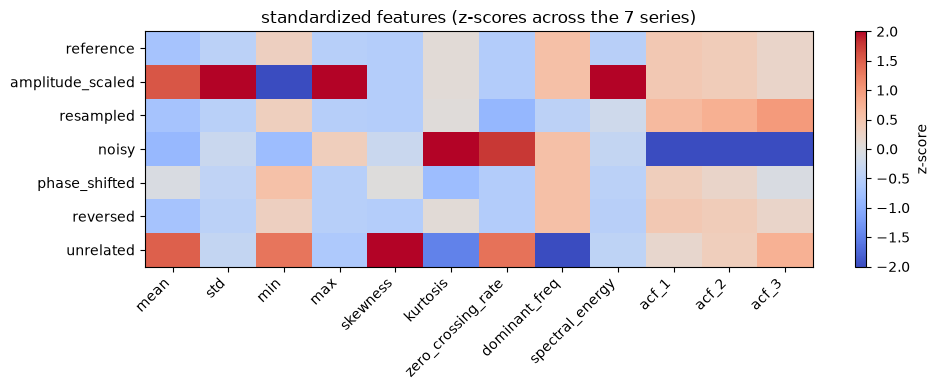

In [7]:
# Visualization: heatmap of the standardized feature matrix. Rows that look alike
# here will end up with a small feature distance.
fig, ax = plt.subplots(figsize=(10, 4))
im = ax.imshow(z_features.values, cmap="coolwarm", vmin=-2, vmax=2, aspect="auto")
ax.set_xticks(range(len(FEATURE_NAMES)), FEATURE_NAMES, rotation=45, ha="right")
ax.set_yticks(range(len(z_features)), z_features.index)
ax.set_title("standardized features (z-scores across the 7 series)")
fig.colorbar(im, label="z-score")
fig.tight_layout()
plt.show()

In [8]:
# Euclidean distance in standardized feature space, reference -> variant.
ref_z = z_features.loc["reference"]
feature_distance = ((z_features - ref_z) ** 2).sum(axis=1) ** 0.5

feature_table = feature_distance.drop("reference").to_frame("feature_distance")
feature_table.sort_values("feature_distance")

,feature_distance
variant,
reversed,0.000
phase_shifted,1.285
resampled,1.399
unrelated,5.398
noisy,5.802
amplitude_scaled,5.978


In [9]:
# How different is `reversed` really, feature by feature?
comparison = pd.DataFrame({
    "reference": features.loc["reference"],
    "reversed": features.loc["reversed"],
})
comparison["abs_diff"] = (comparison["reference"] - comparison["reversed"]).abs()
comparison

,reference,reversed,abs_diff
mean,0.442,0.442,0.000
std,1.472,1.472,0.000
min,-2.496,-2.496,0.000
max,3.449,3.449,0.000
skewness,-0.009,-0.009,0.000
kurtosis,-1.092,-1.092,0.000
zero_crossing_rate,0.047,0.047,0.000
dominant_freq,0.020,0.020,0.000
spectral_energy,325.234,325.234,0.000
acf_1,0.980,0.980,0.000


## Conclusion

The feature ranking is `reversed` (0.000), `phase_shifted` (1.29), `resampled` (1.40),
then `unrelated` (5.40), `noisy` (5.80) and `amplitude_scaled` (5.98). It agrees with
DTW/EDR/ERP on the easy cases — a shifted or resampled signal has essentially the same
summary statistics, and a doubled amplitude shows up immediately in `std`, `min`, `max`
and `spectral_energy` — but it disagrees with all three DP methods in two places.

**`reversed` scores exactly 0.** The last table makes the reason explicit: every one of
the twelve features is *identical* for `reference` and `reversed`, to the last digit.
Moments (mean, std, skewness, kurtosis) do not depend on sample order at all; min/max and
the zero-crossing rate are unchanged by reading the series backwards; the FFT magnitude
spectrum — and therefore dominant frequency and spectral energy — is invariant under time
reversal; and the sample autocorrelation is symmetric, so even the `acf` lags match. In
feature space the two series are the *same point*, whereas DTW, EDR and ERP all placed
`reversed` in the dissimilar half because their monotone alignment cannot map a rising
ramp onto a falling one. Any order-sensitive property one actually cares about needs an
explicit feature for it (e.g. trend slope or a lagged cross-correlation) — otherwise this
approach is blind to it.

**`noisy` is ranked as more dissimilar than `unrelated`.** Additive noise moves several
features a long way at once (`acf_1` 0.98 -> 0.84, zero-crossing rate 0.05 -> 0.16,
kurtosis -1.09 -> -0.73), while the piecewise-constant step signal happens to land close
to the reference on std, spectral energy and the autocorrelations. All three DP methods
rank these two the other way round, and they are right about the intent of the data. The
trade-off is the usual one: `O(n log n)` instead of `O(n·m)`, no alignment needed, series
of different lengths handled for free and a representation that any classifier can
consume — at the price of seeing only what the chosen features happen to encode.